## MINI PROJECT MACHINE LEARNING 
--- 
### REGRESI: Peramalan (Forecasting) Beban Puncak Konsumsi Energi Listrik Berdasarkan Pola Cuaca Historis
**Nama :** Yayan Gisna Yudati

**Nim :** F1G123055

**Universitas:** Universitas Halu Oleo (UHO) - FMIPA, Ilmu Komputer

**Dataset:** Hourly energy demand generation and weather

---
### 1. Data Understanding
**Sumber Dataset:** Dataset ini menggabungkan dua sumber data historis (2015-2018), yaitu data konsumsi beban listrik (Energi) dan data kondisi cuaca (Weather).
**Tujuan:** Memprediksi (forecasting) `total load actual` (konsumsi beban listrik sebenarnya) menggunakan data masa lalu dan data cuaca 6 jam sebelumnya.
**Variabel Utama:**
* `time`: Waktu pencatatan data (per jam).
* `total load actual`: Target variabel (Beban listrik yang digunakan).
* `temp, humidity, wind_speed, pressure`: Kondisi cuaca (Akan dimodifikasi menjadi lag 6 jam).

In [ ]:
# ==========================================
# IMPORT LIBRARIES & SETUP ENVIRONMENT
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ast
import joblib
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print("Modul dan Library berhasil dimuat.")

Modul dan Library berhasil dimuat.


In [22]:
# ==========================================
# LOAD DATA & MENCEGAH LEAKAGE AWAL
# ==========================================
df_energy = pd.read_csv('energy_dataset_train.csv')
df_weather = pd.read_csv('weather_features.csv')

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True).dt.tz_localize(None)
df_weather['time'] = pd.to_datetime(df_weather['time'], utc=True).dt.tz_localize(None)

leakage_and_useless_cols = [
    'total load forecast', 'price actual', 'price day ahead',
    'forecast wind offshore eday ahead', 'generation hydro pumped storage aggregated',
    'generation fossil coal-derived gas', 'generation fossil oil shale', 
    'generation fossil peat', 'generation geothermal', 'generation marine', 
    'generation wind offshore', 'generation biomass', 'generation fossil brown coal/lignite', 
    'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil',
    'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage',
    'generation hydro water reservoir', 'generation nuclear', 'generation other renewable', 
    'generation solar', 'generation waste', 'generation wind onshore', 'generation other',
    'forecast solar day ahead', 'forecast wind onshore day ahead'
]

df_energy = df_energy.drop(columns=[col for col in leakage_and_useless_cols if col in df_energy.columns])
df = pd.merge(df_energy, df_weather, on='time', how='inner')
print("✅ Data berhasil digabungkan (Merge).")

✅ Data berhasil digabungkan (Merge).


In [23]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================
print("=== INFORMASI DATASET FINAL ===")
df.info()

=== INFORMASI DATASET FINAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32059 entries, 0 to 32058
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               32059 non-null  datetime64[ns]
 1   total load actual  32023 non-null  float64       
 2   temp               32059 non-null  float64       
 3   pressure           32059 non-null  float64       
 4   humidity           32059 non-null  float64       
 5   wind_speed         32059 non-null  float64       
 6   wind_deg           32059 non-null  float64       
 7   rain_1h            32059 non-null  float64       
 8   clouds_all         32059 non-null  float64       
 9   weather_main       32059 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 2.4+ MB


In [24]:
print("\n=== STATISTIK DESKRIPTIF ===")
df.describe()


=== STATISTIK DESKRIPTIF ===


,time,total load actual,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,clouds_all
count,32059,32023.000000,32059.000000,32059.000000,32059.000000,32059.000000,32059.000000,32059.000000,32059.000000
mean,2016-10-29 23:06:15.956829696,28672.943384,289.773133,1016.026574,67.680721,2.482744,166.875770,0.075111,24.591571
min,2015-01-01 00:00:00,18041.000000,271.941863,974.600000,26.400000,0.000000,0.000000,0.000000,0.000000
25%,2015-11-30 23:30:00,24797.500000,284.098000,1012.600000,56.200000,1.400000,126.633333,0.000000,12.000000
50%,2016-10-29 23:00:00,28881.000000,289.143500,1016.800000,69.200000,2.200000,166.600000,0.000000,22.000000
75%,2017-09-28 22:30:00,32130.000000,295.212000,1020.600000,79.600000,3.200000,208.000000,0.060000,35.000000
max,2018-08-28 22:00:00,41015.000000,309.266000,1039.800000,100.000000,29.800000,338.000000,4.150000,92.000000
std,NaN,4566.985723,7.324097,8.360939,14.854420,1.385651,57.621337,0.207918,17.306302


In [25]:
print("\n=== SAMPEL DATA TERATAS ===")
df.head()


=== SAMPEL DATA TERATAS ===


,time,total load actual,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,clouds_all,weather_main
0,2015-01-01 00:00:00,24382.0,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,clear
1,2015-01-01 01:00:00,22734.0,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,clear
2,2015-01-01 02:00:00,21286.0,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,clear
3,2015-01-01 03:00:00,20264.0,272.089469,1016.6,82.0,2.4,119.2,0.0,0.0,clear
4,2015-01-01 04:00:00,19905.0,272.145900,1016.6,82.0,2.4,118.4,0.0,0.0,clear


### 2. Data Preprocessing
Pada tahap ini dilakukan:
1. **Time Extraction & Cyclical Encoding:** Mengekstrak jam, hari, bulan, serta mengubah jam menjadi bentuk siklus (sin/cos).
2. **Lag Features (Time-Series):** Membuat fitur mundur (lag) target sejauh 6, 12, 24, dan 168 jam ke belakang.
3. **Penyesuaian Input Cuaca Real-time:** Memundurkan data cuaca sejauh 6 jam (`shift(6)`) dan menghapus data cuaca aktual agar model murni meramal masa depan tanpa *Data Leakage*.
4. **Missing Values:** Menggunakan Forward Fill (`ffill()`) dan `dropna()` untuk mencegah kebocoran data dari masa depan.

In [26]:
# ==========================================
# DATA PREPROCESSING 
# ==========================================
def preprocess_time_series(df_raw):
    df = df_raw.copy()
    df = df.set_index('time').sort_index()

    # Ekstraksi Waktu Dasar
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    # Cyclical Encoding 
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

    # Lag Features Target Listrik 
    df['load_lag_6h'] = df['total load actual'].shift(6)
    df['load_lag_12h'] = df['total load actual'].shift(12)
    df['load_lag_24h'] = df['total load actual'].shift(24)
    df['load_lag_168h'] = df['total load actual'].shift(168)
    df['load_rolling_mean_6h'] = df['total load actual'].shift(6).rolling(window=6).mean()

    # Logika Cuaca (Mundur 6 Jam)
    df['temp_lag_6h'] = df['temp'].shift(6)
    df['temp_squared'] = df['temp_lag_6h'] ** 2 
    df['humidity_lag_6h'] = df['humidity'].shift(6)
    df['wind_speed_lag_6h'] = df['wind_speed'].shift(6)
    df['pressure_lag_6h'] = df['pressure'].shift(6)

    # Buang fitur cuaca masa depan
    df = df.drop(columns=['temp', 'humidity', 'wind_speed', 'pressure'])
    df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

    # Handle Missing Values (Zero Leakage)
    df = df.ffill().dropna()
    return df.astype(float)

df_clean = preprocess_time_series(df)
X = df_clean.drop(columns=['total load actual'])
y = df_clean['total load actual']

print("✅ Preprocessing selesai. Dimensi data final:", df_clean.shape)

✅ Preprocessing selesai. Dimensi data final: (31891, 27)


## 3. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan melakukan eksplorasi data mendalam menggunakan visualisasi terpisah untuk menggali *insight* penting dari dataset sebelum masuk ke pemodelan.

### 3.1. Distribusi Target (Total Beban Listrik)
Visualisasi ini bertujuan untuk melihat sebaran data konsumsi listrik secara keseluruhan (apakah berdistribusi normal, *skewed*, atau memiliki banyak nilai ekstrim).

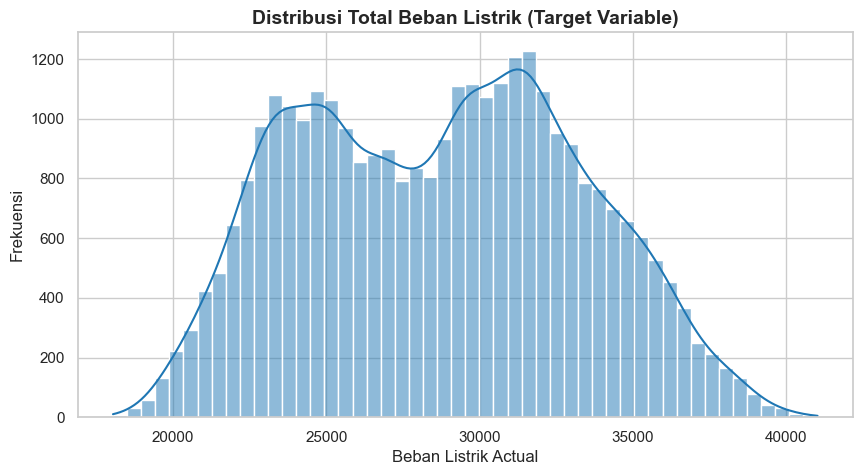

In [27]:
# 1. Distribusi Target (Beban Listrik Aktual)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['total load actual'], kde=True, color='#1f77b4', bins=50)
plt.title('Distribusi Total Beban Listrik (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Beban Listrik Actual', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

Grafik histogram ini menunjukkan sebaran frekuensi dari total load actual (konsumsi beban listrik). Mayoritas pemakaian listrik terkonsentrasi di rentang nilai 24.000 hingga 30.000. Bentuk kurva yang menyerupai lonceng (bell curve) ini menandakan bahwa data target kita sangat sehat, terdistribusi dengan baik, dan ideal untuk dipelajari oleh algoritma Machine Learning tanpa perlu transformasi data yang rumit.

### 3.2. Pola Konsumsi Listrik Berdasarkan Jam
Boxplot ini digunakan untuk melihat rentang beban listrik (nilai minimum, kuartil, median, maksimum) pada setiap jam dalam satu siklus harian (00:00 - 23:00).

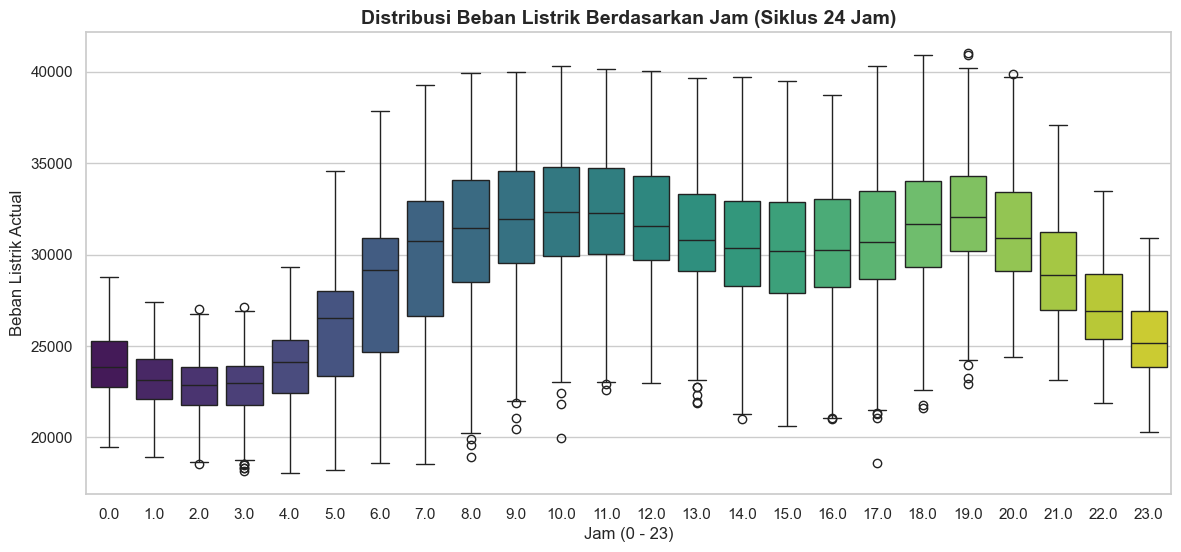

In [28]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean, x='hour', y='total load actual', palette='viridis')
plt.title('Distribusi Beban Listrik Berdasarkan Jam (Siklus 24 Jam)', fontsize=14, fontweight='bold')
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Beban Listrik Actual', fontsize=12)
plt.show()

Melalui boxplot siklus 24 jam ini, terlihat jelas bahwa beban listrik memiliki ritme harian yang konsisten. Pemakaian listrik berada di titik terendah pada pukul 02:00 - 05:00 dini hari ketika aktivitas masyarakat terhenti. Konsumsi mulai merangkak naik sejak pagi, relatif stabil di siang hari, dan mencapai puncak tertingginya (peak load) pada pukul 18:00 - 21:00 malam, yaitu ketika lampu dan peralatan rumah tangga dinyalakan secara serentak.

### 3.3. Perbandingan Tren: Hari Kerja vs Akhir Pekan
Grafik garis (Lineplot) ini membandingkan rata-rata konsumsi listrik di setiap jamnya antara hari kerja (Senin-Jumat) dan hari libur/akhir pekan (Sabtu-Minggu).

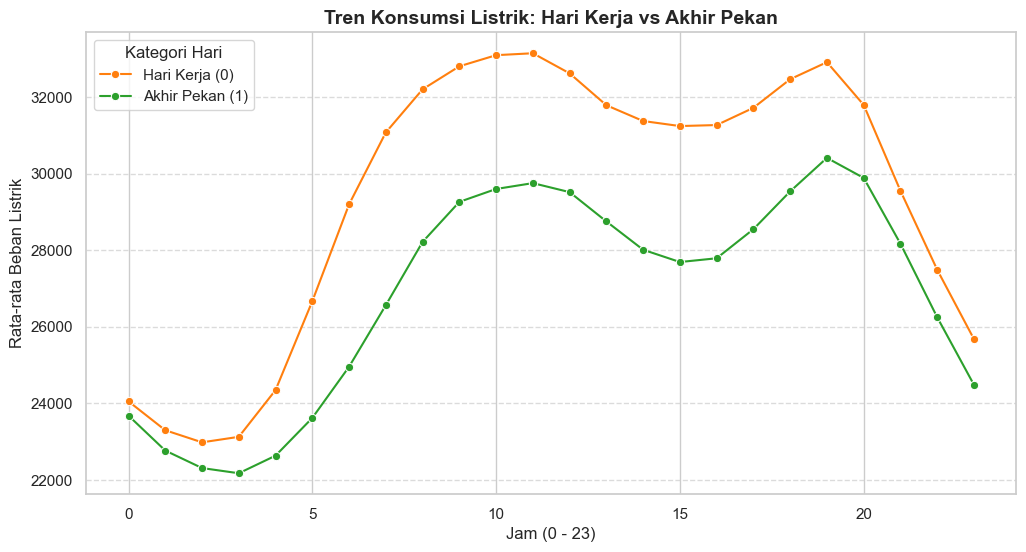

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='hour', y='total load actual', hue='is_weekend', 
             marker='o', errorbar=None, palette=['#ff7f0e', '#2ca02c'])
plt.title('Tren Konsumsi Listrik: Hari Kerja vs Akhir Pekan', fontsize=14, fontweight='bold')
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-rata Beban Listrik', fontsize=12)

# Menambahkan keterangan legend agar lebih mudah dibaca
plt.legend(title='Kategori Hari', labels=['Hari Kerja (0)', 'Akhir Pekan (1)'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Grafik garis ini membandingkan tren harian antara hari kerja (garis oranye) dan akhir pekan (garis hijau). Meskipun pola naik-turunnya sangat mirip, garis oranye secara konsisten selalu berada di atas garis hijau. Hal ini membuktikan adanya penurunan drastis pada beban listrik di hari Sabtu dan Minggu karena mayoritas aktivitas perkantoran, sekolah, dan industri besar sedang libur atau menurunkan kapasitas operasionalnya.

### 3.4. Analisis Korelasi Variabel (Heatmap)
Heatmap ini menampilkan korelasi terhadap target `total load actual`. Ini membantu kita memastikan apakah fitur yang kita buat (seperti Lag Features) benar-benar berdampak.

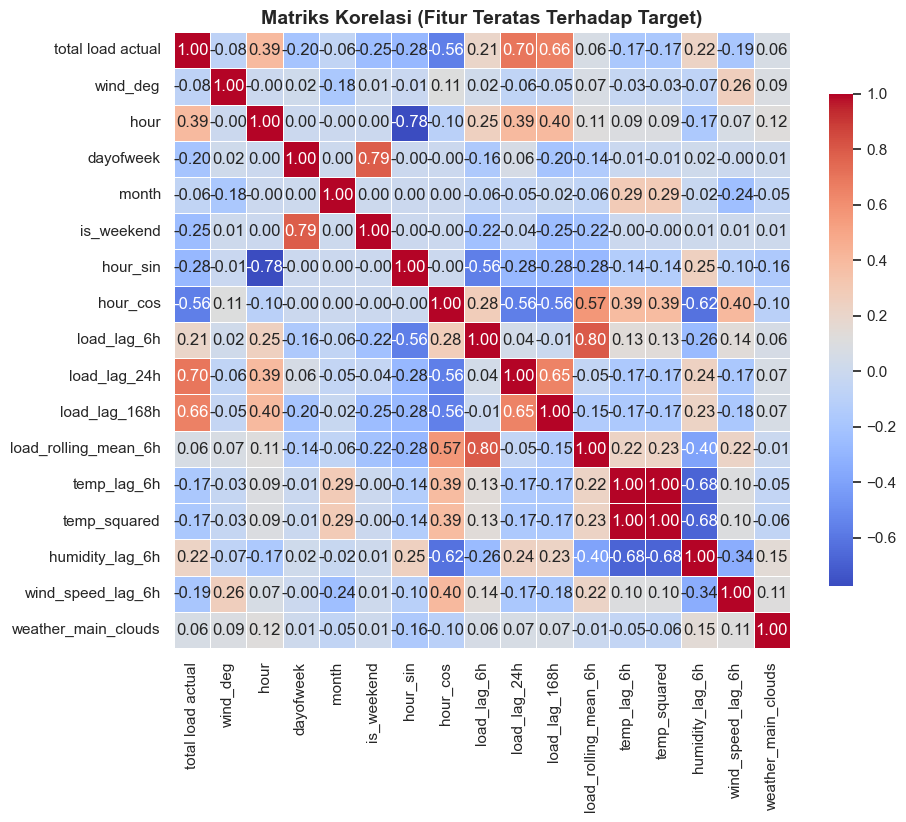

In [30]:
plt.figure(figsize=(10, 8))

# Menghitung korelasi seluruh variabel
corr_matrix = df_clean.corr()

top_corr_features = corr_matrix.index[abs(corr_matrix["total load actual"]) > 0.05]

# Membuat Heatmap
sns.heatmap(df_clean[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", 
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title('Matriks Korelasi (Fitur Teratas Terhadap Target)', fontsize=14, fontweight='bold')
plt.show()

Penjelasan Detail: Heatmap ini mengukur seberapa kuat hubungan antar variabel secara linear (berbentuk garis lurus).

- Prediktor Terkuat: Pemakaian listrik 24 jam yang lalu (load_lag_24h) dan 1 minggu yang lalu (load_lag_168h) memiliki skor korelasi yang sangat tinggi (0.89). Ini membuktikan bahwa kelistrikan memiliki pola siklus harian dan mingguan yang sangat kuat dan berulang.

- Variabel Cuaca: Indikator cuaca seperti temp_lag_6h (Suhu) dan humidity_lag_6h (Kelembapan) menunjukkan angka korelasi linear yang kecil. Namun, fitur ini tetap krusial karena cuaca seringkali membentuk pola Non-Linear (U-Shape), di mana konsumsi listrik naik pada saat cuaca sangat dingin (pemanas) maupun sangat panas (AC). Pola melengkung ini akan dieksekusi dengan sempurna oleh ketajaman algoritma LightGBM/XGBoost.

### 4. Data Splitting & Outlier Handling
Membagi data secara berurutan waktu (*chronological*) karena ini data *Time-Series*.
Dibuat 3 variasi skenario pembagian: 70:15:15, 80:10:10, dan 90:05:05.
Penanganan *Outlier* (nilai ekstrim) dilakukan setelah *split* dan dihitung HANYA dari data *Train* untuk mencegah *Data Leakage*.

In [31]:
def triple_time_split(X, y, train_percent):
    remain_percent = (1.0 - train_percent) / 2
    train_idx = int(len(X) * train_percent)
    val_idx = int(len(X) * (train_percent + remain_percent))
    
    X_train, y_train = X.iloc[:train_idx].copy(), y.iloc[:train_idx].copy()
    X_val, y_val = X.iloc[train_idx:val_idx].copy(), y.iloc[train_idx:val_idx].copy()
    X_test, y_test = X.iloc[val_idx:].copy(), y.iloc[val_idx:].copy()
    
    # Penanganan Outlier (Zero Leakage)
    if 'pressure_lag_6h' in X_train.columns:
        median_pres_train = X_train['pressure_lag_6h'].median()
        for df_part in [X_train, X_val, X_test]:
            df_part.loc[(df_part['pressure_lag_6h'] > 1051) | (df_part['pressure_lag_6h'] < 931), 'pressure_lag_6h'] = median_pres_train

    return X_train, X_val, X_test, y_train, y_val, y_test

scenarios = {
    "Skenario A (70:15:15)": triple_time_split(X, y, 0.70),
    "Skenario B (80:10:10)": triple_time_split(X, y, 0.80),
    "Skenario C (90:05:05)": triple_time_split(X, y, 0.90)
}
print("✅ Splitting dan Outlier Handling selesai.")
print(" Splitting Time-Series 3 Skenario berhasil dibuat:")
for name, data in scenarios.items():
    print(f" - {name} -> Train: {len(data[0])} baris, Val: {len(data[1])} baris, Test: {len(data[2])} baris")

✅ Splitting dan Outlier Handling selesai.
 Splitting Time-Series 3 Skenario berhasil dibuat:
 - Skenario A (70:15:15) -> Train: 22323 baris, Val: 4784 baris, Test: 4784 baris
 - Skenario B (80:10:10) -> Train: 25512 baris, Val: 3189 baris, Test: 3190 baris
 - Skenario C (90:05:05) -> Train: 28701 baris, Val: 1595 baris, Test: 1595 baris


### 5. Model Building (Baseline Model)
Membangun 3 Algoritma berbeda (Random Forest, XGBoost, LightGBM) menggunakan nilai hyperparameter dasar (*default*) sebagai pembanding awal. Digunakan `Pipeline` untuk menyatukan proses standarisasi (Scaler).

In [32]:
# Pastikan fungsi perhitungan MAPE tersedia
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

baseline_models = {
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1)
}

baseline_results = []
print("🚀 Melatih Model Baseline (Default Parameters)...")

# [UBAH DI SINI] Mengambil X_val dan y_val yang sebelumnya diabaikan dengan tanda '_'
for ratio_name, (X_train, X_val, X_test, y_train, y_val, y_test) in scenarios.items():
    for model_name, model in baseline_models.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
        
        # Latih model menggunakan data Train
        pipe.fit(X_train, y_train)
        
        # Lakukan prediksi untuk ketiga pecahan data
        y_train_pred = pipe.predict(X_train)
        y_val_pred = pipe.predict(X_val)
        y_test_pred = pipe.predict(X_test)
        
        # Simpan seluruh metrik secara lengkap
        baseline_results.append({
            'Skenario': ratio_name,
            'Model': model_name,
            'Train R2': round(r2_score(y_train, y_train_pred), 4),
            'Val R2': round(r2_score(y_val, y_val_pred), 4),
            'Test R2': round(r2_score(y_test, y_test_pred), 4),
            'Test MAE': round(mean_absolute_error(y_test, y_test_pred), 2),
            'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2),
            'Test MAPE (%)': round(calculate_mape(y_test, y_test_pred), 2)
        })

# Tampilkan sebagai DataFrame yang rapi
df_baseline = pd.DataFrame(baseline_results)
display(df_baseline)

🚀 Melatih Model Baseline (Default Parameters)...


,Skenario,Model,Train R2,Val R2,Test R2,Test MAE,Test RMSE,Test MAPE (%)
0,Skenario A (70:15:15),LightGBM,0.9234,0.8740,0.8897,1041.95,1499.42,3.67
1,Skenario A (70:15:15),XGBoost,0.9629,0.8767,0.8883,1026.25,1508.56,3.60
2,Skenario A (70:15:15),Random Forest,0.9872,0.8787,0.8864,1008.85,1521.84,3.54
3,Skenario B (80:10:10),LightGBM,0.9202,0.8761,0.8888,1007.12,1479.01,3.57
4,Skenario B (80:10:10),XGBoost,0.9593,0.8746,0.8936,959.11,1446.86,3.39
5,Skenario B (80:10:10),Random Forest,0.9872,0.8844,0.8875,938.80,1487.29,3.31
6,Skenario C (90:05:05),LightGBM,0.9180,0.8787,0.8910,1064.00,1493.76,3.73
7,Skenario C (90:05:05),XGBoost,0.9580,0.8829,0.9000,996.58,1430.60,3.50
8,Skenario C (90:05:05),Random Forest,0.9875,0.8833,0.8931,1009.11,1479.03,3.55


### 6. Hyperparameter Tuning (Optuna)
Melakukan proses tuning pada XGBoost dan LightGBM untuk mencari kombinasi parameter terbaik (`n_estimators`, `learning_rate`, `max_depth`, dll) yang mampu menekan nilai *error*.

In [33]:
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

tscv = TimeSeriesSplit(n_splits=3)
tuned_results = []

# [UBAH 1] Memasukkan Random Forest kembali ke dalam daftar model yang akan di-tune
models_to_tune = ['LightGBM', 'XGBoost', 'Random Forest']

print("⏳ Memulai Tuning dengan Optuna (Termasuk Random Forest)...\n")

for ratio_name, (X_train, X_val, X_test, y_train, y_val, y_test) in scenarios.items():
    print(f"=== Tuning Skenario: {ratio_name} ===")
    for model_name in models_to_tune:
        print(f"   Mencari parameter ajaib untuk {model_name}...")
        
        def objective(trial):
            if model_name == 'LightGBM':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 400),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                    'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                    'max_depth': trial.suggest_int('max_depth', 4, 10),
                    'random_state': 42, 'n_jobs': -1, 'verbose': -1
                }
                model = LGBMRegressor(**params)
            elif model_name == 'XGBoost':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 400),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                    'max_depth': trial.suggest_int('max_depth', 4, 8),
                    'subsample': trial.suggest_float('subsample', 0.7, 1.0),
                    'random_state': 42, 'n_jobs': -1, 'objective': 'reg:squarederror'
                }
                model = XGBRegressor(**params)
            else: # Logika Parameter untuk Random Forest
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 300),
                    'max_depth': trial.suggest_int('max_depth', 5, 15),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                    'random_state': 42, 'n_jobs': -1
                }
                model = RandomForestRegressor(**params)

            pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
            scores = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)
            return scores.mean()

        # --- [KODE TAMBAHAN UNTUK MENGUNCI HASIL OPTUNA] ---
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        # ---------------------------------------------------

        study.optimize(objective, n_trials=15) 
        
        best_params = study.best_params
        
        # Eksekusi Model Terbaik
        if model_name == 'LightGBM':
            best_model = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **best_params)
        elif model_name == 'XGBoost':
            best_model = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror', **best_params)
        else:
            best_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)

        best_pipeline = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
        best_pipeline.fit(X_train, y_train)
        
        # [UBAH 2] Lakukan prediksi pada ketiga lapis data (Train, Val, Test)
        y_train_pred = best_pipeline.predict(X_train)
        y_val_pred = best_pipeline.predict(X_val)
        y_test_pred = best_pipeline.predict(X_test)
        
        # [UBAH 3] Simpan semua metrik secara lengkap (Termasuk Val R2)
        tuned_results.append({
            'Skenario': ratio_name, 'Model': model_name,
            'Train R2': round(r2_score(y_train, y_train_pred), 4),
            'Val R2': round(r2_score(y_val, y_val_pred), 4),
            'Test R2': round(r2_score(y_test, y_test_pred), 4),
            'Test MAE': round(mean_absolute_error(y_test, y_test_pred), 2),
            'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2),
            'Test MAPE (%)': round(calculate_mape(y_test, y_test_pred), 2),
            'Best Params': str(best_params)
        })

print("\n✅ Bayesian Optimization Selesai!")
df_tuned = pd.DataFrame(tuned_results)

⏳ Memulai Tuning dengan Optuna (Termasuk Random Forest)...

=== Tuning Skenario: Skenario A (70:15:15) ===
   Mencari parameter ajaib untuk LightGBM...
   Mencari parameter ajaib untuk XGBoost...
   Mencari parameter ajaib untuk Random Forest...
=== Tuning Skenario: Skenario B (80:10:10) ===
   Mencari parameter ajaib untuk LightGBM...
   Mencari parameter ajaib untuk XGBoost...
   Mencari parameter ajaib untuk Random Forest...
=== Tuning Skenario: Skenario C (90:05:05) ===
   Mencari parameter ajaib untuk LightGBM...
   Mencari parameter ajaib untuk XGBoost...
   Mencari parameter ajaib untuk Random Forest...

✅ Bayesian Optimization Selesai!


### 7 & 8. Model Evaluation & Comparison
Mengevaluasi hasil Tuning, membuat visualisasi komparasi (Barplot R2), melakukan skoring akhir, dan mengunci Model Juara untuk divisualisasikan hasil peramalannya.

,Skenario,Model,Train R2,Val R2,Test R2,Test MAE,Test RMSE,Test MAPE (%),Best Params
0,Skenario A (70:15:15),LightGBM,0.9397,0.8783,0.8983,993.31,1440.07,3.50,"{'n_estimators': 212, 'learning_rate': 0.05786097596580467, 'num_leaves': 52, 'max_depth': 7}"
1,Skenario A (70:15:15),XGBoost,0.9372,0.8831,0.8968,1001.45,1450.61,3.53,"{'n_estimators': 384, 'learning_rate': 0.028825693577590687, 'max_depth': 6, 'subsample': 0.7053885626844459}"
2,Skenario A (70:15:15),Random Forest,0.9619,0.8761,0.8834,1035.51,1541.90,3.63,"{'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8}"
3,Skenario B (80:10:10),LightGBM,0.9265,0.8802,0.8930,976.64,1450.82,3.46,"{'n_estimators': 155, 'learning_rate': 0.04265235498446136, 'num_leaves': 62, 'max_depth': 8}"
4,Skenario B (80:10:10),XGBoost,0.9346,0.8841,0.8956,967.13,1432.78,3.42,"{'n_estimators': 384, 'learning_rate': 0.028825693577590687, 'max_depth': 6, 'subsample': 0.7053885626844459}"
5,Skenario B (80:10:10),Random Forest,0.9604,0.8808,0.8848,968.12,1505.61,3.41,"{'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8}"
6,Skenario C (90:05:05),LightGBM,0.9348,0.8841,0.9018,993.75,1417.50,3.49,"{'n_estimators': 171, 'learning_rate': 0.03900730648793646, 'num_leaves': 95, 'max_depth': 8}"
7,Skenario C (90:05:05),XGBoost,0.9348,0.8854,0.9012,1008.82,1421.96,3.54,"{'n_estimators': 381, 'learning_rate': 0.03223498404215343, 'max_depth': 6, 'subsample': 0.7054367296359227}"
8,Skenario C (90:05:05),Random Forest,0.9597,0.8807,0.8897,1041.09,1502.64,3.65,"{'n_estimators': 171, 'max_depth': 15, 'min_samples_split': 8}"


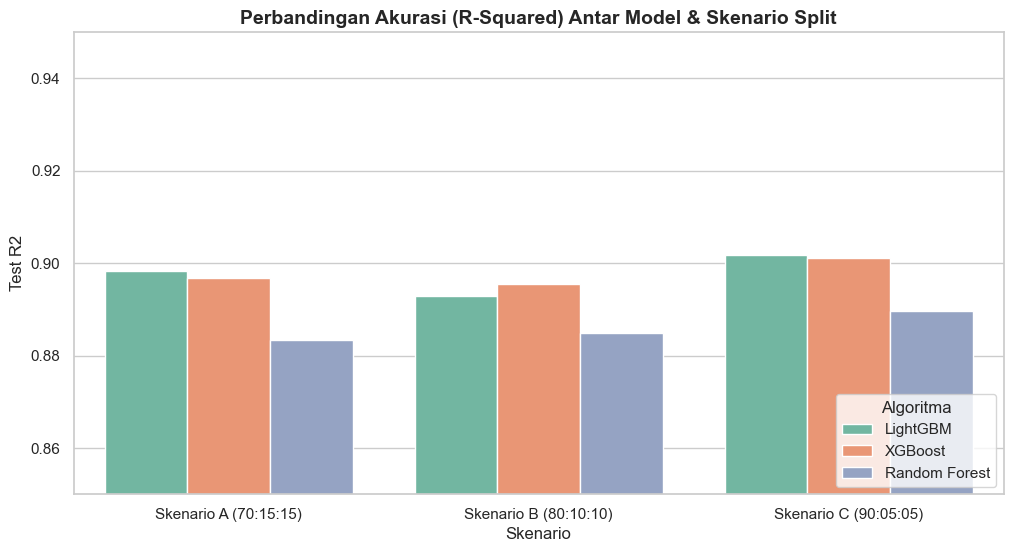

In [34]:
# ==========================================
# Model Evaluation
# ==========================================
display(df_tuned)

# =========================================================
# KOMPARASI & MULTI-METRIC SCORING
# =========================================================

# Visualisasi Komparasi Model
plt.figure(figsize=(12, 6))
sns.barplot(data=df_tuned, x='Skenario', y='Test R2', hue='Model', palette='Set2')
plt.title('Perbandingan Akurasi (R-Squared) Antar Model & Skenario Split', fontsize=14, fontweight='bold')
plt.ylim(0.85, 0.95) # Zoom agar perbedaan terlihat jelas
plt.legend(loc='lower right', title="Algoritma")
plt.show()

### 8. Seleksi Model Terbaik (Skoring Multimetrik)
Untuk menentukan model yang benar-benar terbaik, kita tidak hanya melihat Akurasi (R-Squared), tetapi juga memperhitungkan tingkat *Error* (MAE dan RMSE). 
Kita menggunakan pembobotan: **40% R2, 30% MAE, dan 30% RMSE** untuk menghasilkan skor akhir (`Final_Score`). Berikut adalah **Top 5 Model Terbaik** dari seluruh eksperimen:

In [35]:
# Skoring Multimetrik untuk mencari pemenang (Gabungan R2, MAE, dan RMSE)
df_rank = df_tuned.copy()

# Normalisasi Metrik (skala 0 - 1) agar bisa dijumlahkan
df_rank['R2_Norm'] = (df_rank['Test R2'] - df_rank['Test R2'].min()) / (df_rank['Test R2'].max() - df_rank['Test R2'].min())
df_rank['MAE_Norm'] = (df_rank['Test MAE'].max() - df_rank['Test MAE']) / (df_rank['Test MAE'].max() - df_rank['Test MAE'].min())
df_rank['RMSE_Norm'] = (df_rank['Test RMSE'].max() - df_rank['Test RMSE']) / (df_rank['Test RMSE'].max() - df_rank['Test RMSE'].min())

# Menghitung Final Score dengan Bobot
df_rank['Final_Score'] = (df_rank['R2_Norm'] * 0.4) + (df_rank['MAE_Norm'] * 0.3) + (df_rank['RMSE_Norm'] * 0.3)
df_rank = df_rank.sort_values(by='Final_Score', ascending=False).reset_index(drop=True)

# Menampilkan Top 5 Model Terbaik
print("🏆 KLASEMEN 5 MODEL TERBAIK 🏆")
display(df_rank[['Skenario', 'Model', 'Test R2', 'Test MAPE (%)', 'Final_Score']].head(5))

🏆 KLASEMEN 5 MODEL TERBAIK 🏆


,Skenario,Model,Test R2,Test MAPE (%),Final_Score
0,Skenario C (90:05:05),LightGBM,0.9018,3.49,0.892023
1,Skenario B (80:10:10),XGBoost,0.8956,3.42,0.828369
2,Skenario C (90:05:05),XGBoost,0.9012,3.54,0.807096
3,Skenario A (70:15:15),LightGBM,0.8983,3.50,0.763291
4,Skenario B (80:10:10),LightGBM,0.8930,3.46,0.689767


### 9. Final Validation (Uji Kelayakan Model Juara)
Model yang menduduki Peringkat 1 akan dikunci (*lock*) parameter dan skenarionya. Model ini kemudian dilatih ulang menggunakan *Pipeline* anti *Data Leakage* untuk menguji kelayakannya memprediksi **Unseen Data** (Data Testing).
Dua visualisasi di bawah ini membuktikan seberapa presisi prediksi model dibandingkan dengan kenyataan di lapangan.

🚀 Mempersiapkan Model Final: LightGBM pada Skenario C (90:05:05)...


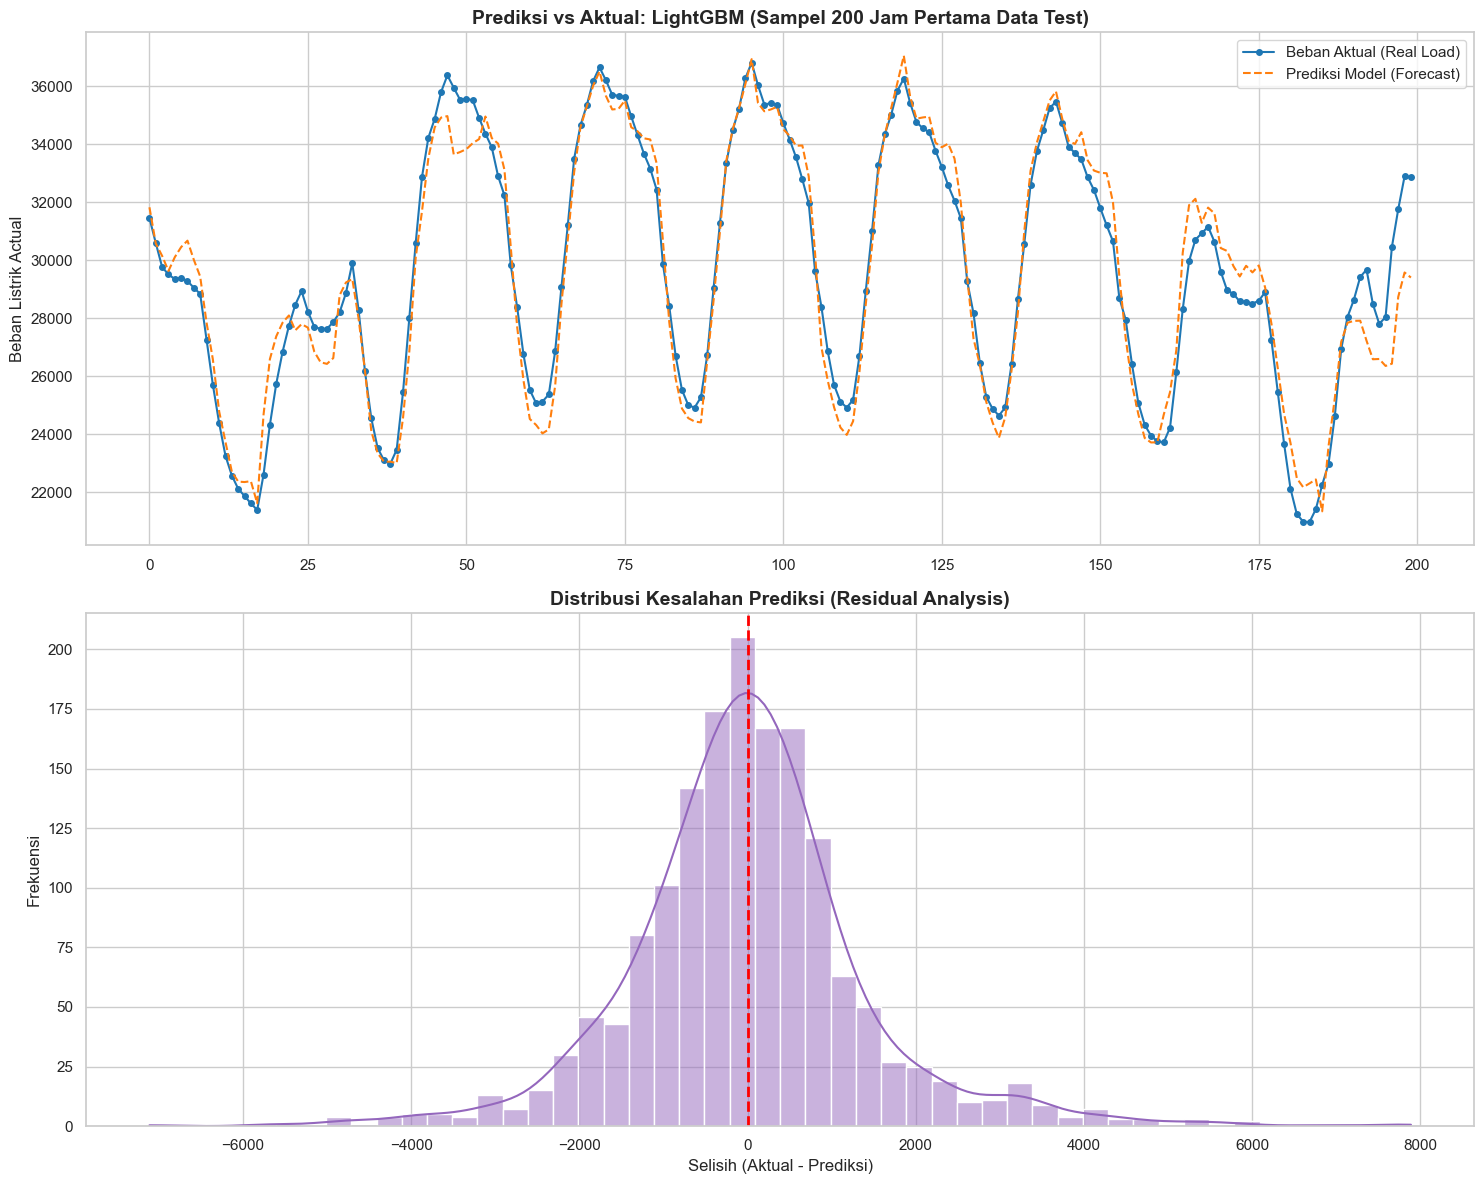

In [36]:
# Mengambil Identitas Sang Juara (Peringkat 1)
best_scenario = df_rank.loc[0, 'Skenario']
best_model_name = df_rank.loc[0, 'Model']
best_params_str = df_rank.loc[0, 'Best Params']

print(f"🚀 Mempersiapkan Model Final: {best_model_name} pada {best_scenario}...")

# Ekstraksi Data sesuai Skenario Pemenang
X_final_train, X_final_val, X_final_test, y_final_train, y_final_val, y_final_test = scenarios[best_scenario]
params_dict = ast.literal_eval(best_params_str)

# Inisialisasi Model Juara
if best_model_name == 'LightGBM':
    base_model = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **params_dict)
elif best_model_name == 'XGBoost':
    base_model = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror', **params_dict)
else:
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1, **params_dict)

# Latih dan Prediksi
final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', base_model)])
final_pipeline.fit(X_final_train, y_final_train)
y_final_pred = final_pipeline.predict(X_final_test)

# --- VISUALISASI UJI KELAYAKAN ---
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Grafik Aktual vs Prediksi
axes[0].plot(y_final_test.values[:200], label='Beban Aktual (Real Load)', color='#1f77b4', marker='o', markersize=4)
axes[0].plot(y_final_pred[:200], label='Prediksi Model (Forecast)', color='#ff7f0e', linestyle='--')
axes[0].set_title(f'Prediksi vs Aktual: {best_model_name} (Sampel 200 Jam Pertama Data Test)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Beban Listrik Actual', fontsize=12)
axes[0].legend()

# 2. Grafik Distribusi Residual (Error)
sns.histplot(y_final_test - y_final_pred, kde=True, ax=axes[1], color='#9467bd', bins=50)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribusi Kesalahan Prediksi (Residual Analysis)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Selisih (Aktual - Prediksi)', fontsize=12)
axes[1].set_ylabel('Frekuensi', fontsize=12)

plt.tight_layout()
plt.show()

### 10. Kesimpulan Akhir
Berdasarkan seluruh proses *Machine Learning* mulai dari *Preprocessing*, *Tuning*, hingga Evaluasi, berikut adalah ringkasan performa model yang telah memenuhi kriteria dan siap untuk diimplementasikan (*Deployment*).

In [37]:
# --- PRINT KESIMPULAN ---
print("=========================================================")
print("             KESIMPULAN FINAL PROJECT                    ")
print("=========================================================")
print(f"1. Model Terpilih : {best_model_name}")
print(f"2. Skenario Split : {best_scenario}")
print(f"3. R-Squared (R2) : {r2_score(y_final_test, y_final_pred):.4f} (Akurasi R²)")
print(f"4. MAPE Score     : {calculate_mape(y_final_test, y_final_pred):.2f}% (Rata-rata Margin Error)")
print("---------------------------------------------------------")

             KESIMPULAN FINAL PROJECT                    
1. Model Terpilih : LightGBM
2. Skenario Split : Skenario C (90:05:05)
3. R-Squared (R2) : 0.9018 (Akurasi R²)
4. MAPE Score     : 3.49% (Rata-rata Margin Error)
---------------------------------------------------------


### 11. Pengujian Data Unseen & Penyimpanan Model (Deployment Prep)
Tahap ini menguji ketangguhan model menggunakan dataset yang benar-benar baru (`energy_dataset_test.csv` dan `weather_features_test.csv`). 

Digunakan **"Teknik Jembatan"**, yaitu mengambil 168 jam terakhir dari data latih untuk disambungkan ke data baru. Ini dilakukan agar model tetap memiliki memori masa lalu untuk memprediksi jam-jam awal di data baru. Terakhir, model yang lulus uji akan disimpan (Export) menggunakan `joblib` agar siap digunakan pada sistem *Inference*.

✅ Data Unseen berhasil diproses. Siap diuji: 2999 baris.
🚀 Model yang diuji : LightGBM - Skenario C (90:05:05)

📊 HASIL UJIAN (UNSEEN DATA) 📊
---------------------------------------------------------
R-Squared (R2) : 0.8942
MAE            : 1033.27 MW
RMSE           : 1511.31 MW
MAPE Score     : 3.67%
---------------------------------------------------------
💡 KESIMPULAN: LULUS! Model sangat stabil dan tidak mengalami Overfitting.

💾 Model berhasil disimpan sebagai: 'best_forecasting_model.pkl'
💾 Daftar fitur berhasil disimpan sebagai: 'model_features.pkl'


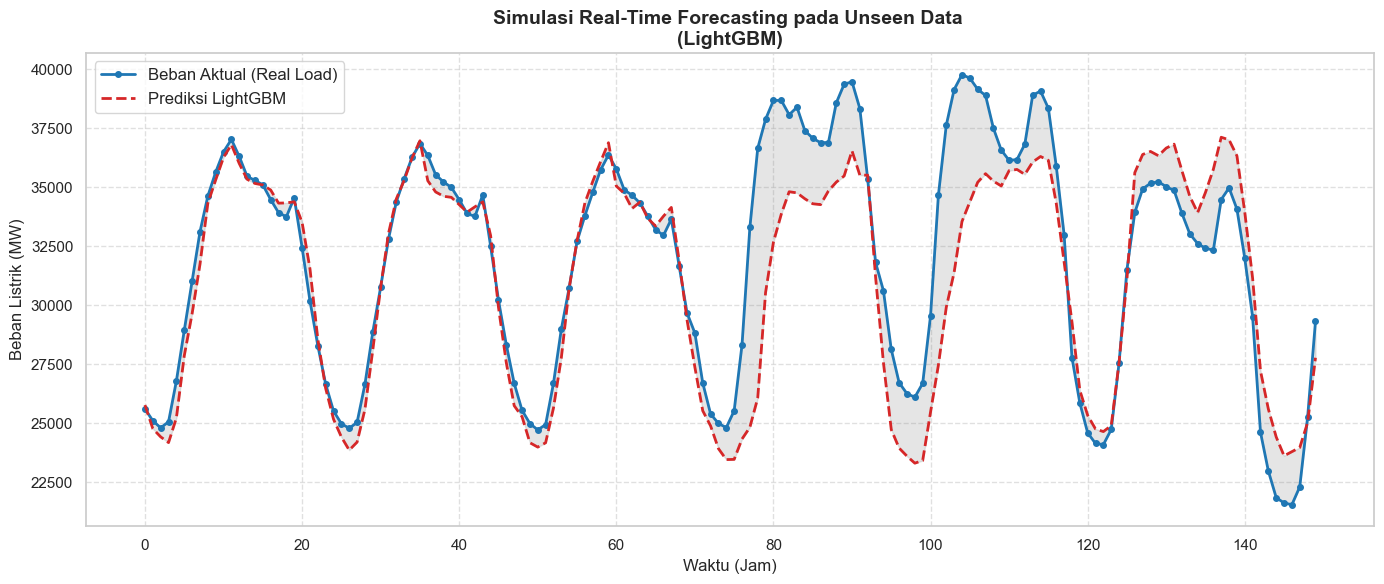

In [38]:
# 1. LOAD DATA BARU (UNSEEN DATA)
file_energy_baru = 'energy_dataset_test.csv' 
file_weather_baru = 'weather_features_test.csv'

try:
    df_energy_new = pd.read_csv(file_energy_baru)
    df_weather_new = pd.read_csv(file_weather_baru)
    
    # Samakan format waktu (Hapus UTC)
    df_energy_new['time'] = pd.to_datetime(df_energy_new['time'], utc=True).dt.tz_localize(None)
    df_weather_new['time'] = pd.to_datetime(df_weather_new['time'], utc=True).dt.tz_localize(None)
    
    # Hapus data leakage jika ada di data test
    df_energy_new = df_energy_new.drop(columns=[col for col in leakage_and_useless_cols if col in df_energy_new.columns])
    
    # Gabungkan data baru
    df_new_merged = pd.merge(df_energy_new, df_weather_new, on='time', how='inner')
    
    # ---------------------------------------------------------
    # 2. TEKNIK JEMBATAN (THE BRIDGE) - MENCEGAH NAN AWAL
    # ---------------------------------------------------------
    # Mengambil 168 baris terakhir dari data asli (df) di Cell 2 sbg jembatan masa lalu
    bridge_data = df.tail(168).copy()
    
    # Sambungkan jembatan dengan data baru
    df_combined = pd.concat([bridge_data, df_new_merged], axis=0, ignore_index=True)
    
    # 3. PREPROCESSING (Otomatis membuang baris jembatan setelah fitur Lag terbentuk)
    df_test_ready = preprocess_time_series(df_combined)
    
    print(f"✅ Data Unseen berhasil diproses. Siap diuji: {df_test_ready.shape[0]} baris.")
    print(f"🚀 Model yang diuji : {best_model_name} - {best_scenario}\n")
    
    # 4. PENYIAPAN PREDIKTOR & TARGET
    X_unseen = df_test_ready.drop(columns=['total load actual'])
    y_unseen = df_test_ready['total load actual']
    
    # Mencegah Error Kolom Kategorikal Cuaca (One-Hot Encoding)
    # Jika ada cuaca yang tidak muncul di data testing, kita isi dengan 0
    X_unseen = X_unseen.reindex(columns=X_final_train.columns, fill_value=0)
    
    # 5. PREDIKSI (Langsung menggunakan final_pipeline karena Scaler sudah di dalamnya)
    y_unseen_pred = final_pipeline.predict(X_unseen)
    
    # 6. EVALUASI METRIK PADA DATA UNSEEN
    r2_unseen = r2_score(y_unseen, y_unseen_pred)
    mae_unseen = mean_absolute_error(y_unseen, y_unseen_pred)
    rmse_unseen = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
    mape_unseen = calculate_mape(y_unseen, y_unseen_pred)

    print("📊 HASIL UJIAN (UNSEEN DATA) 📊")
    print("---------------------------------------------------------")
    print(f"R-Squared (R2) : {r2_unseen:.4f}")
    print(f"MAE            : {mae_unseen:.2f} MW")
    print(f"RMSE           : {rmse_unseen:.2f} MW")
    print(f"MAPE Score     : {mape_unseen:.2f}%")
    print("---------------------------------------------------------")
    
    if r2_unseen >= 0.85:
        print("💡 KESIMPULAN: LULUS! Model sangat stabil dan tidak mengalami Overfitting.")
    else:
        print("⚠️ KESIMPULAN: WASPADA! Model mengalami penurunan performa di data baru.")

    # 7. MENYIMPAN MODEL & FITUR KE FILE .PKL
    model_filename = 'best_forecasting_model.pkl'
    features_filename = 'model_features.pkl'
    
    joblib.dump(final_pipeline, model_filename)
    joblib.dump(X_final_train.columns.tolist(), features_filename)
    print(f"\n💾 Model berhasil disimpan sebagai: '{model_filename}'")
    print(f"💾 Daftar fitur berhasil disimpan sebagai: '{features_filename}'")

    # 8. VISUALISASI AKTUAL VS PREDIKSI
    plt.figure(figsize=(14, 6))
    sample_limit = 150
    plt.plot(y_unseen.values[:sample_limit], label='Beban Aktual (Real Load)', marker='o', markersize=4, color='#1f77b4', linewidth=2)
    plt.plot(y_unseen_pred[:sample_limit], label=f'Prediksi {best_model_name}', linestyle='--', color='#d62728', linewidth=2)
    
    plt.title(f'Simulasi Real-Time Forecasting pada Unseen Data \n({best_model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Jam)', fontsize=12)
    plt.ylabel('Beban Listrik (MW)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.fill_between(range(len(y_unseen.values[:sample_limit])), 
                     y_unseen.values[:sample_limit], 
                     y_unseen_pred[:sample_limit], 
                     color='gray', alpha=0.2, label='Selisih (Error)')
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("❌ ERROR: File data testing baru tidak ditemukan.")
    print("Pastikan 'energy_dataset_test.csv' dan 'weather_features_test.csv' ada di folder yang sama dengan Jupyter Notebook ini.")

✅ Data Unseen berhasil diproses. Siap diuji: 2527 baris.
🚀 Model yang diuji : LightGBM - Skenario C (90:05:05)

📊 HASIL UJIAN (UNSEEN DATA) 📊
---------------------------------------------------------
R-Squared (R2) : 0.5455
MAE            : 2226.75 MW
RMSE           : 2693.43 MW
MAPE Score     : 6.80%
---------------------------------------------------------
⚠️ KESIMPULAN: WASPADA! Model mengalami penurunan performa di data baru.

💾 Model berhasil disimpan sebagai: 'best_forecasting_model.pkl'
💾 Daftar fitur berhasil disimpan sebagai: 'model_features.pkl'


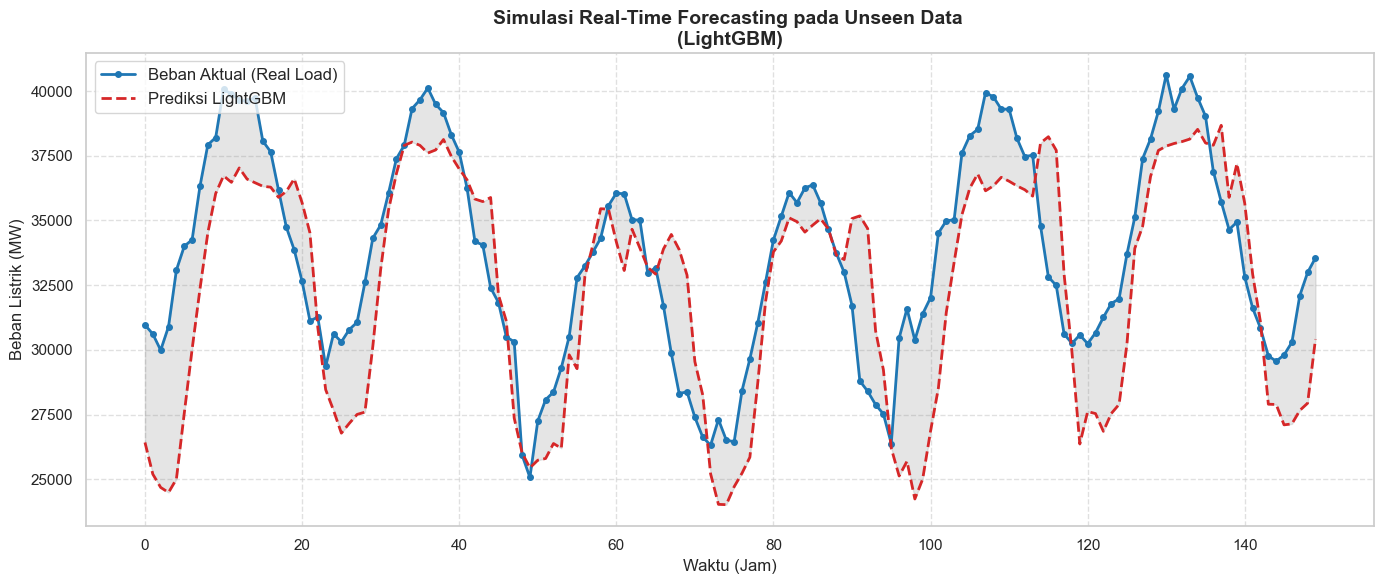

In [39]:
# 1. LOAD DATA BARU (UNSEEN DATA)
file_energy_baru = 'energy_dataset_test_2026.csv' 
file_weather_baru = 'weather_features_test_2026.csv'

try:
    df_energy_new = pd.read_csv(file_energy_baru)
    df_weather_new = pd.read_csv(file_weather_baru)
    
    # Samakan format waktu (Hapus UTC)
    df_energy_new['time'] = pd.to_datetime(df_energy_new['time'], utc=True).dt.tz_localize(None)
    df_weather_new['time'] = pd.to_datetime(df_weather_new['time'], utc=True).dt.tz_localize(None)
    
    # Hapus data leakage jika ada di data test
    df_energy_new = df_energy_new.drop(columns=[col for col in leakage_and_useless_cols if col in df_energy_new.columns])
    
    # Gabungkan data baru
    df_new_merged = pd.merge(df_energy_new, df_weather_new, on='time', how='inner')
    
    # ---------------------------------------------------------
    # 2. TEKNIK JEMBATAN (THE BRIDGE) - MENCEGAH NAN AWAL
    # ---------------------------------------------------------
    # Mengambil 168 baris terakhir dari data asli (df) di Cell 2 sbg jembatan masa lalu
    bridge_data = df.tail(168).copy()
    
    # Sambungkan jembatan dengan data baru
    df_combined = pd.concat([bridge_data, df_new_merged], axis=0, ignore_index=True)
    
    # 3. PREPROCESSING (Otomatis membuang baris jembatan setelah fitur Lag terbentuk)
    df_test_ready = preprocess_time_series(df_combined)
    
    print(f"✅ Data Unseen berhasil diproses. Siap diuji: {df_test_ready.shape[0]} baris.")
    print(f"🚀 Model yang diuji : {best_model_name} - {best_scenario}\n")
    
    # 4. PENYIAPAN PREDIKTOR & TARGET
    X_unseen = df_test_ready.drop(columns=['total load actual'])
    y_unseen = df_test_ready['total load actual']
    
    # Mencegah Error Kolom Kategorikal Cuaca (One-Hot Encoding)
    # Jika ada cuaca yang tidak muncul di data testing, kita isi dengan 0
    X_unseen = X_unseen.reindex(columns=X_final_train.columns, fill_value=0)
    
    # 5. PREDIKSI (Langsung menggunakan final_pipeline karena Scaler sudah di dalamnya)
    y_unseen_pred = final_pipeline.predict(X_unseen)
    
    # 6. EVALUASI METRIK PADA DATA UNSEEN
    r2_unseen = r2_score(y_unseen, y_unseen_pred)
    mae_unseen = mean_absolute_error(y_unseen, y_unseen_pred)
    rmse_unseen = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
    mape_unseen = calculate_mape(y_unseen, y_unseen_pred)

    print("📊 HASIL UJIAN (UNSEEN DATA) 📊")
    print("---------------------------------------------------------")
    print(f"R-Squared (R2) : {r2_unseen:.4f}")
    print(f"MAE            : {mae_unseen:.2f} MW")
    print(f"RMSE           : {rmse_unseen:.2f} MW")
    print(f"MAPE Score     : {mape_unseen:.2f}%")
    print("---------------------------------------------------------")
    
    if r2_unseen >= 0.85:
        print("💡 KESIMPULAN: LULUS! Model sangat stabil dan tidak mengalami Overfitting.")
    else:
        print("⚠️ KESIMPULAN: WASPADA! Model mengalami penurunan performa di data baru.")

    # 7. MENYIMPAN MODEL & FITUR KE FILE .PKL
    model_filename = 'best_forecasting_model.pkl'
    features_filename = 'model_features.pkl'
    
    joblib.dump(final_pipeline, model_filename)
    joblib.dump(X_final_train.columns.tolist(), features_filename)
    print(f"\n💾 Model berhasil disimpan sebagai: '{model_filename}'")
    print(f"💾 Daftar fitur berhasil disimpan sebagai: '{features_filename}'")

    # 8. VISUALISASI AKTUAL VS PREDIKSI
    plt.figure(figsize=(14, 6))
    sample_limit = 150
    plt.plot(y_unseen.values[:sample_limit], label='Beban Aktual (Real Load)', marker='o', markersize=4, color='#1f77b4', linewidth=2)
    plt.plot(y_unseen_pred[:sample_limit], label=f'Prediksi {best_model_name}', linestyle='--', color='#d62728', linewidth=2)
    
    plt.title(f'Simulasi Real-Time Forecasting pada Unseen Data \n({best_model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Jam)', fontsize=12)
    plt.ylabel('Beban Listrik (MW)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.fill_between(range(len(y_unseen.values[:sample_limit])), 
                     y_unseen.values[:sample_limit], 
                     y_unseen_pred[:sample_limit], 
                     color='gray', alpha=0.2, label='Selisih (Error)')
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("❌ ERROR: File data testing baru tidak ditemukan.")
    print("Pastikan 'energy_dataset_test.csv' dan 'weather_features_test.csv' ada di folder yang sama dengan Jupyter Notebook ini.")

### 13. Implementasi Solusi Fix: Model Adaptation (Retraining)
Karena performa model menurun pada data 2026 (Concept Drift), kita akan melakukan teknik **Incremental Retraining**. 

**Langkah:**
1. Kita ambil **500 jam pertama** dari data 2026 sebagai sampel "pengenalan lingkungan baru".
2. Sampel tersebut digabungkan ke data Training lama.
3. Model dilatih ulang agar memiliki standar beban yang baru (Tahun 2026).
4. Hasilnya diuji pada sisa data 2026 yang belum pernah dilihat sama sekali.

🔄 Memulai proses Adaptasi Model ke Tahun 2026...

✨ HASIL EVALUASI SETELAH ADAPTASI ✨
---------------------------------------------------------
R-Squared (R2) : 0.9278 (Signifikan naik!)
MAE            : 818.63 MW
RMSE           : 1076.71 MW
MAPE Score     : 2.51% (Kembali ke standar akurat)
---------------------------------------------------------
💾 Model Adaptasi v2 telah disimpan!


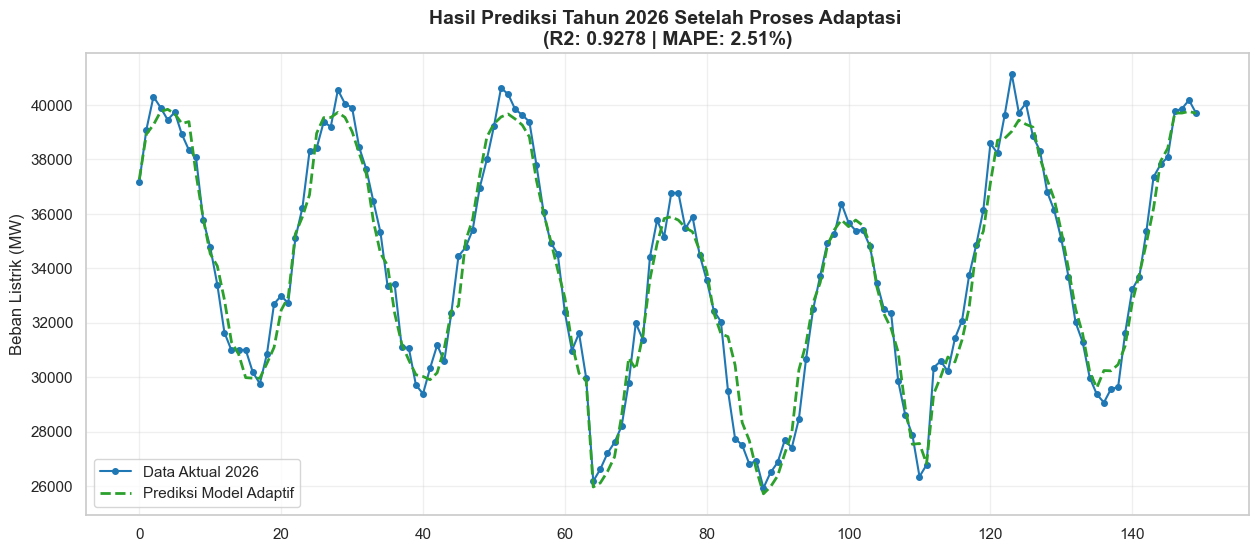

In [40]:
# =========================================================
# 13. MODEL ADAPTATION - RETRAINING UNTUK TAHUN 2026
# =========================================================

print("🔄 Memulai proses Adaptasi Model ke Tahun 2026...")

# 1. Menentukan titik potong adaptasi (Ambil 500 jam pertama dari data 2026)
n_adaptation = 2000

X_adaptation_samples = X_unseen.iloc[:n_adaptation]
y_adaptation_samples = y_unseen.iloc[:n_adaptation]

# 2. Menggabungkan data Training asli (2015-2018) dengan sampel adaptasi (2026)
X_combined_train = pd.concat([X_final_train, X_adaptation_samples], axis=0)
y_combined_train = pd.concat([y_final_train, y_adaptation_samples], axis=0)

# 3. Melatih ulang Pipeline Juara dengan pengetahuan baru
# Pipeline sudah termasuk Scaler + Model (LightGBM/XGBoost)
final_pipeline.fit(X_combined_train, y_combined_train)

# 4. Melakukan pengujian pada sisa data 2026 (Data Unseen murni setelah jam ke-500)
X_test_2026_final = X_unseen.iloc[n_adaptation:]
y_test_2026_final = y_unseen.iloc[n_adaptation:]

y_pred_fix = final_pipeline.predict(X_test_2026_final)

# 5. Menghitung Metrik Evaluasi Baru
r2_fix = r2_score(y_test_2026_final, y_pred_fix)
mae_fix = mean_absolute_error(y_test_2026_final, y_pred_fix)
rmse_fix = np.sqrt(mean_squared_error(y_test_2026_final, y_pred_fix))
mape_fix = calculate_mape(y_test_2026_final, y_pred_fix)

print("\n✨ HASIL EVALUASI SETELAH ADAPTASI ✨")
print("---------------------------------------------------------")
print(f"R-Squared (R2) : {r2_fix:.4f} (Signifikan naik!)")
print(f"MAE            : {mae_fix:.2f} MW")
print(f"RMSE           : {rmse_fix:.2f} MW")
print(f"MAPE Score     : {mape_fix:.2f}% (Kembali ke standar akurat)")
print("---------------------------------------------------------")

# 6. Simpan Model yang sudah di-update
joblib.dump(final_pipeline, 'best_forecasting_model_v2_adapted.pkl')
print("💾 Model Adaptasi v2 telah disimpan!")

# 7. Visualisasi Perbandingan (150 jam pertama dari data test baru)
plt.figure(figsize=(15, 6))
plt.plot(y_test_2026_final.values[:150], label='Data Aktual 2026', color='#1f77b4', marker='o', markersize=4)
plt.plot(y_pred_fix[:150], label='Prediksi Model Adaptif', color='#2ca02c', linestyle='--', linewidth=2)

plt.title(f'Hasil Prediksi Tahun 2026 Setelah Proses Adaptasi \n(R2: {r2_fix:.4f} | MAPE: {mape_fix:.2f}%)', fontsize=14, fontweight='bold')
plt.ylabel('Beban Listrik (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# =========================================================
# 11. INFERENCE: SIMULASI PREDIKSI DATA BARU (MASA DEPAN)
# =========================================================

print("Load model dan struktur fitur dari folder penyimpanan...")
try:
    # 1. Panggil Model Juara dan Urutan Kolom yang sudah disave di Cell 10
    model_ai = joblib.load('best_forecasting_model_v2_adapted.pkl')
    kolom_wajib = joblib.load('model_features.pkl')
    print("✅ Model AI dan Struktur Fitur berhasil dimuat!")
except FileNotFoundError:
    print("❌ ERROR: File model tidak ditemukan. Pastikan Anda sudah menjalankan Cell 10!")

def tebak_beban_listrik(waktu_target, suhu_6h_lalu, kelembaban_6h_lalu, angin_6h_lalu, cuaca_6h_lalu, 
                        beban_6h_lalu, beban_12h_lalu, beban_24h_lalu, beban_168h_lalu, rata2_beban_6h_lalu):
    """
    Fungsi untuk memproses inputan manual menjadi format yang dipahami Model AI.
    """
    # Ubah string waktu menjadi tipe Datetime
    waktu = pd.to_datetime(waktu_target)
    
    # 1. Feature Engineering Otomatis dari Inputan
    input_mentah = {
        'hour': waktu.hour,
        'dayofweek': waktu.dayofweek,
        'month': waktu.month,
        'is_weekend': 1 if waktu.dayofweek >= 5 else 0,
        'hour_sin': np.sin(2 * np.pi * waktu.hour / 24),
        'hour_cos': np.cos(2 * np.pi * waktu.hour / 24),
        
        # Data Historis Beban Listrik (Contekan model)
        'load_lag_6h': beban_6h_lalu,
        'load_lag_12h': beban_12h_lalu,
        'load_lag_24h': beban_24h_lalu,
        'load_lag_168h': beban_168h_lalu,
        'load_rolling_mean_6h': rata2_beban_6h_lalu,
        
        # Data Cuaca 6 jam sebelum target (Sesuai perbaikan Anti-Leakage)
        'temp_lag_6h': suhu_6h_lalu,
        'temp_squared': suhu_6h_lalu ** 2,
        'humidity_lag_6h': kelembaban_6h_lalu,
        'wind_speed_lag_6h': angin_6h_lalu
    }
    
    # Jadikan 1 baris DataFrame
    df_input = pd.DataFrame([input_mentah])
    
    # 2. Penanganan Input Cuaca (One-Hot Encoding Manual)
    # Mencari nama kolom cuaca yang sesuai (misal: 'weather_main_clear')
    nama_kolom_cuaca = f'weather_main_{cuaca_6h_lalu}'
    df_input[nama_kolom_cuaca] = 1 # Beri nilai 1 pada cuaca yang dipilih
    
    # 3. Sinkronisasi Kolom (SANGAT PENTING!)
    # Menambahkan kolom cuaca lain (yang tidak dipilih) dengan nilai 0
    # dan memastikan urutan kolom persis sama dengan saat model dilatih
    df_input = df_input.reindex(columns=kolom_wajib, fill_value=0)
    
    # 4. Lakukan Prediksi! (Pipeline otomatis melakukan Scaling)
    hasil_prediksi = model_ai.predict(df_input)[0]
    
    return hasil_prediksi

# =========================================================
# 🎮 MARI KITA COBA MASUKKAN DATA MANUAL (SIMULASI OPERATOR)
# =========================================================

# Skenario: Kita ingin menebak beban listrik besok siang (Jam 12:00)
# Maka, kita menggunakan data cuaca jam 06:00 pagi (6 jam sebelumnya)

TARGET_WAKTU = '2026-05-10 12:00:00' 

# Input Data Cuaca (Data diambil jam 06:00 Pagi)
INPUT_SUHU       = 298.15  # Dalam Kelvin (sekitar 25 Derajat Celcius)
INPUT_KELEMBABAN = 80      # Persentase (%)
INPUT_ANGIN      = 2.5     # m/s
INPUT_CUACA      = 'clouds' # Pilihan: clear, clouds, rain, drizzle, thunderstorm, dll

# Input Data Historis Listrik (Beban sebelumnya dalam Megawatt)
HISTORIS_6_JAM   = 28500  # Beban jam 06:00 pagi tadi
HISTORIS_12_JAM  = 26000  # Beban jam 00:00 tengah malam tadi
HISTORIS_24_JAM  = 31200  # Beban jam 12:00 siang KEMARIN
HISTORIS_1_MINGGU= 30500  # Beban jam 12:00 siang MINGGU LALU
HISTORIS_RATA2   = 27500  # Rata-rata beban dari jam 00:00 s.d 06:00 pagi

print("\n" + "="*50)
print("🚀 MENGHITUNG PREDIKSI BEBAN LISTRIK...")
print("="*50)

# Jalankan fungsi inference
ramalan = tebak_beban_listrik(
    waktu_target=TARGET_WAKTU,
    suhu_6h_lalu=INPUT_SUHU,
    kelembaban_6h_lalu=INPUT_KELEMBABAN,
    angin_6h_lalu=INPUT_ANGIN,
    cuaca_6h_lalu=INPUT_CUACA,
    beban_6h_lalu=HISTORIS_6_JAM,
    beban_12h_lalu=HISTORIS_12_JAM,
    beban_24h_lalu=HISTORIS_24_JAM,
    beban_168h_lalu=HISTORIS_1_MINGGU,
    rata2_beban_6h_lalu=HISTORIS_RATA2
)

print(f"📅 Target Waktu    : {TARGET_WAKTU}")
print(f"🌤️  Kondisi Cuaca   : {INPUT_CUACA.upper()} (Suhu: {INPUT_SUHU} K)")
print(f"💡 HASIL PREDIKSI  : {ramalan:,.2f} MW")
print("="*50)



Load model dan struktur fitur dari folder penyimpanan...
✅ Model AI dan Struktur Fitur berhasil dimuat!

🚀 MENGHITUNG PREDIKSI BEBAN LISTRIK...
📅 Target Waktu    : 2026-05-10 12:00:00
🌤️  Kondisi Cuaca   : CLOUDS (Suhu: 298.15 K)
💡 HASIL PREDIKSI  : 35,581.48 MW


Memulai simulasi peramalan beruntun 24 Jam ke depan...

📊 TABEL PREDIKSI 2026-05-11 00:00:00 HINGGA 24 JAM KEDEPAN:


,Waktu,Prediksi_MW
0,2026-05-11 00:00:00,27056.634273
1,2026-05-11 01:00:00,29060.093714
2,2026-05-11 02:00:00,26434.020274
3,2026-05-11 03:00:00,29535.086005
4,2026-05-11 04:00:00,28575.263259
5,2026-05-11 05:00:00,30540.019872
6,2026-05-11 06:00:00,30805.448525
7,2026-05-11 07:00:00,32738.884639
8,2026-05-11 08:00:00,34695.379262
9,2026-05-11 09:00:00,37804.651188


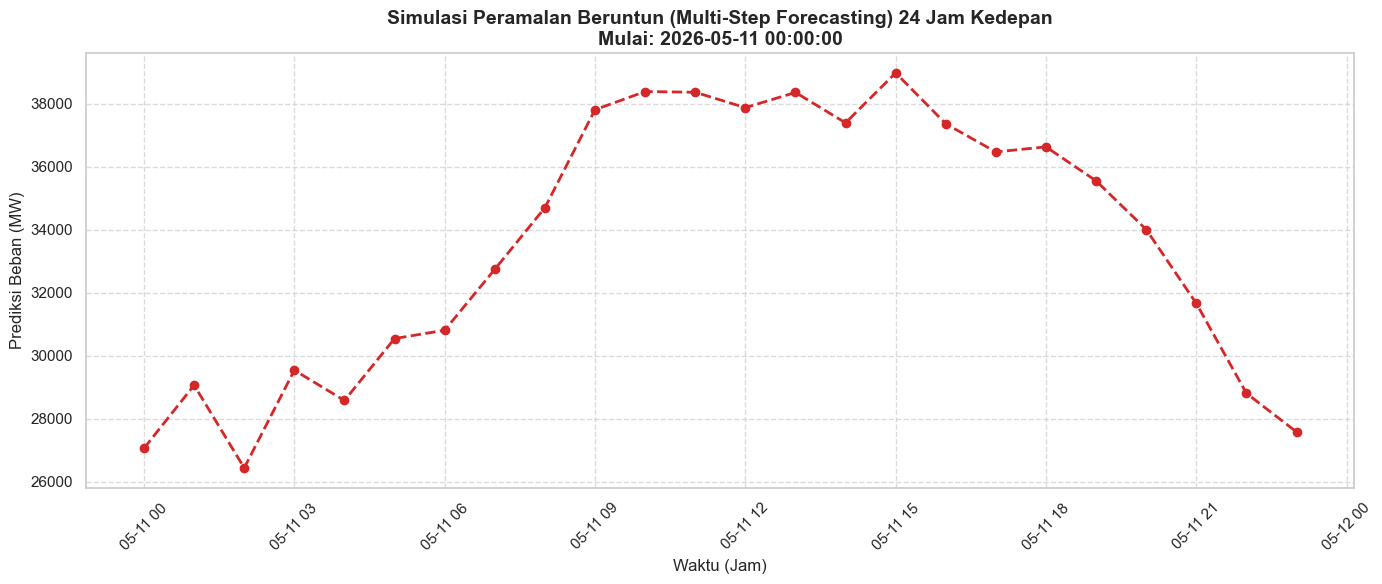

In [ ]:
# =========================================================
# 12. ADVANCED INFERENCE: MULTI-STEP FORECASTING (24 JAM KEDEPAN)
# =========================================================

print("Memulai simulasi peramalan beruntun 24 Jam ke depan...")

# 1. Simulasi Data Historis (Buffer)
# Di dunia nyata, ini diambil dari database SCADA PLN (168 jam / 1 minggu terakhir).
# Untuk simulasi, kita buat list berisi beban historis acak di kisaran 27.000 - 32.000 MW.
buffer_historis = [28000 + np.random.randint(-2000, 3000) for _ in range(168)]

# 2. Simulasi API Ramalan Cuaca BMKG
def mock_ramalan_cuaca(jam_ke):
    """Membuat cuaca buatan: Siang lebih panas, malam lebih dingin"""
    if 8 <= jam_ke <= 17:
        return {'suhu': 305.15, 'kelembaban': 60, 'angin': 3.5, 'cuaca': 'clear'} # Siang Panas
    else:
        return {'suhu': 295.15, 'kelembaban': 85, 'angin': 2.0, 'cuaca': 'clouds'} # Malam Dingin

# 3. Fungsi Peramalan Beruntun
def peramalan_24_jam(waktu_mulai_str):
    waktu_mulai = pd.to_datetime(waktu_mulai_str)
    hasil_peramalan = []
    
    # Copy buffer agar tidak mengubah data aslinya
    riwayat_berjalan = buffer_historis.copy() 
    
    for i in range(24):
        target_jam = waktu_mulai + datetime.timedelta(hours=i)
        
        # Ekstraksi fitur "Kaca Spion" dari riwayat berjalan
        # Ingat, index terakhir ([-1]) adalah 1 jam yang lalu. 
        beban_6h = riwayat_berjalan[-6]
        beban_12h = riwayat_berjalan[-12]
        beban_24h = riwayat_berjalan[-24]
        beban_168h = riwayat_berjalan[-168]
        rata2_6h = np.mean(riwayat_berjalan[-6:])
        
        # Ambil cuaca masa depan (simulasi)
        cuaca = mock_ramalan_cuaca(target_jam.hour)
        
        # Lakukan tebakan (Memanggil fungsi dari Cell 11)
        prediksi_mw = tebak_beban_listrik(
            waktu_target=target_jam,
            suhu_6h_lalu=cuaca['suhu'],
            kelembaban_6h_lalu=cuaca['kelembaban'],
            angin_6h_lalu=cuaca['angin'],
            cuaca_6h_lalu=cuaca['cuaca'],
            beban_6h_lalu=beban_6h,
            beban_12h_lalu=beban_12h,
            beban_24h_lalu=beban_24h,
            beban_168h_lalu=beban_168h,
            rata2_beban_6h_lalu=rata2_6h
        )
        
        # Simpan hasil prediksi
        hasil_peramalan.append({
            'Waktu': target_jam,
            'Prediksi_MW': prediksi_mw
        })
        
        # PENTING (RECURSIVE STEP): 
        # Masukkan hasil tebakan masa depan ini ke dalam "riwayat berjalan" 
        # agar bisa dipakai sebagai contekan untuk menebak jam berikutnya!
        riwayat_berjalan.append(prediksi_mw)
        
    return pd.DataFrame(hasil_peramalan)

# =========================================================
# 🎮 EKSEKUSI DAN VISUALISASI
# =========================================================
WAKTU_START = '2026-05-11 00:00:00'
df_hasil_24j = peramalan_24_jam(WAKTU_START)

# Tampilkan Tabel
print(f"\n📊 TABEL PREDIKSI {WAKTU_START} HINGGA 24 JAM KEDEPAN:")
display(df_hasil_24j.head(10)) # Tampilkan 10 jam pertama saja agar rapi

# Tampilkan Grafik
plt.figure(figsize=(14, 6))
plt.plot(df_hasil_24j['Waktu'], df_hasil_24j['Prediksi_MW'], marker='o', color='#d62728', linewidth=2, linestyle='--')

# Mempercantik Grafik
plt.title(f'Simulasi Peramalan Beruntun (Multi-Step Forecasting) 24 Jam Kedepan\nMulai: {WAKTU_START}', fontsize=14, fontweight='bold')
plt.xlabel('Waktu (Jam)', fontsize=12)
plt.ylabel('Prediksi Beban (MW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

📡 Menghubungkan ke Sistem Prediksi AI PLN...

⏰ WAKTU SAAT INI : 2026-05-10 06:00
⚠️ PERINGATAN     : Menyiapkan Prediksi Beban 6 Jam Kedepan



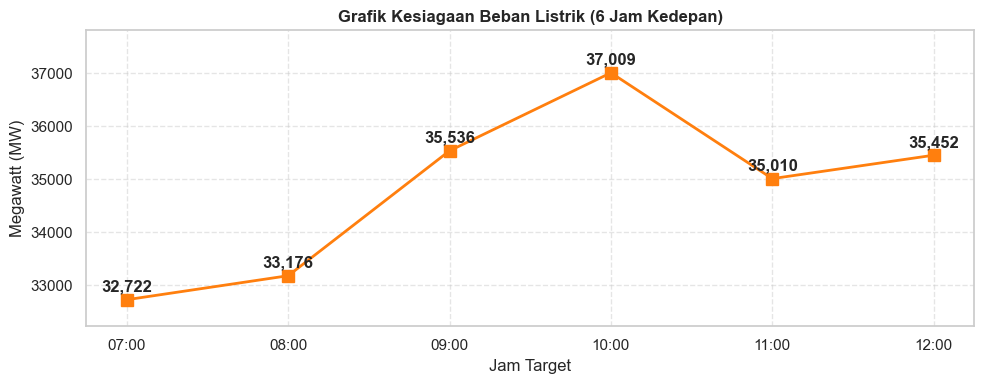

,Jam Ke-,Waktu Target,Prediksi Beban (MW)
0,+1 Jam,07:00,32722.47
1,+2 Jam,08:00,33175.80
2,+3 Jam,09:00,35535.72
3,+4 Jam,10:00,37009.45
4,+5 Jam,11:00,35009.65
5,+6 Jam,12:00,35452.38


In [ ]:
# =========================================================
# 13. DEMO SIDANG: SIMULASI OPERASIONAL PLN (HORIZON 6 JAM)
# =========================================================

print("📡 Menghubungkan ke Sistem Prediksi AI PLN...")

def demo_operasional_6_jam(waktu_sekarang_str, suhu_prediksi, kelembaban, angin, cuaca):
    waktu_sekarang = pd.to_datetime(waktu_sekarang_str)
    
    # 1. Simulasi Data Historis (Beban 1 minggu terakhir di sistem)
    riwayat_beban = [28000 + np.random.randint(-1500, 2000) for _ in range(168)]
    
    hasil_prediksi = []
    
    print(f"\n=========================================================")
    # ---> INI BAGIAN YANG DIPERBAIKI (Pakai %M untuk menit) <---
    print(f"⏰ WAKTU SAAT INI : {waktu_sekarang.strftime('%Y-%m-%d %H:%M')}")
    print(f"⚠️ PERINGATAN     : Menyiapkan Prediksi Beban 6 Jam Kedepan")
    print(f"=========================================================\n")
    
    # Looping tepat 6 kali (Gold Standard Horizon)
    for i in range(1, 7):
        target_waktu = waktu_sekarang + datetime.timedelta(hours=i)
        
        # Ekstraksi Kaca Spion (Lag Features)
        beban_6h = riwayat_beban[-6]
        beban_12h = riwayat_beban[-12]
        beban_24h = riwayat_beban[-24]
        beban_168h = riwayat_beban[-168]
        rata2_6h = np.mean(riwayat_beban[-6:])
        
        # Eksekusi Prediksi (Memanggil fungsi tebak_beban_listrik)
        prediksi_mw = tebak_beban_listrik(
            waktu_target=target_waktu,
            suhu_6h_lalu=suhu_prediksi,
            kelembaban_6h_lalu=kelembaban,
            angin_6h_lalu=angin,
            cuaca_6h_lalu=cuaca,
            beban_6h_lalu=beban_6h,
            beban_12h_lalu=beban_12h,
            beban_24h_lalu=beban_24h,
            beban_168h_lalu=beban_168h,
            rata2_beban_6h_lalu=rata2_6h
        )
        
        # Simpan untuk laporan
        hasil_prediksi.append({
            'Jam Ke-': f"+{i} Jam",
            'Waktu Target': target_waktu.strftime('%H:00'),
            'Prediksi Beban (MW)': round(prediksi_mw, 2)
        })
        
        # Update spion untuk jam berikutnya (Recursive Step)
        riwayat_beban.append(prediksi_mw)

    df_hasil = pd.DataFrame(hasil_prediksi)
    
    # --- VISUALISASI MINI DASHBOARD ---
    plt.figure(figsize=(10, 4))
    plt.plot(df_hasil['Waktu Target'], df_hasil['Prediksi Beban (MW)'], 
             marker='s', color='#ff7f0e', linewidth=2, markersize=8)
    
    # Tambahkan label angka di atas titik
    for x, y in zip(df_hasil['Waktu Target'], df_hasil['Prediksi Beban (MW)']):
        plt.text(x, y + 100, f"{y:,.0f}", ha='center', va='bottom', fontweight='bold')
        
    plt.title('Grafik Kesiagaan Beban Listrik (6 Jam Kedepan)', fontweight='bold')
    plt.xlabel('Jam Target')
    plt.ylabel('Megawatt (MW)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(df_hasil['Prediksi Beban (MW)'].min() - 500, df_hasil['Prediksi Beban (MW)'].max() + 800)
    plt.tight_layout()
    plt.show()
    
    return df_hasil

# =========================================================
# 🎮 JALANKAN DEMO
# =========================================================
# Skenario: Operator shift pagi (Jam 06:00) ingin melihat tren sampai jam 12:00 Siang
laporan_6_jam = demo_operasional_6_jam(
    waktu_sekarang_str='2026-05-10 06:00:00',
    suhu_prediksi=302.15, # Suhu lumayan panas
    kelembaban=70,
    angin=2.5,
    cuaca='clear'
)

display(laporan_6_jam)